# D1-06 Data quality checks and linking workflow

This notebook continues the Day 1 import story with a foreground inventory file.

We use the `lci-carbon-fiber.xlsx` inventory file to inspect unlinked exchanges, apply a migration, write a clean foreground database linked to BAFU, and activate one small set of activity parameters directly from the Excel source file.

## Learning goals

- Import a realistic foreground Excel inventory with `bw2io.ExcelImporter`.
- Inspect statistics and unlinked exchanges after applying strategies.
- Distinguish technosphere and biosphere linking problems.
- Apply a migration file to repair common naming / mapping issues.
- Write a linked foreground database into the course project.
- Re-import the same foreground with active parameters.
- Inspect `ActivityParameter` and `ParameterizedExchange` objects.
- Recalculate scores after changing parameter values.
- Build a bonus Monte Carlo from sampled parameter values.

## Background references

- Mutel, C. (2017). *Brightway: An open source framework for life cycle assessment*. Journal of Open Source Software, 2(12), 236. https://doi.org/10.21105/joss.00236
- Benitez, A., Wulf, C., de Palmenaer, A., Lengersdorf, M., Röding, T., Grube, T., et al. (2021). Ecological assessment of fuel cell electric vehicles with special focus on type IV carbon fiber hydrogen tank. *Journal of Cleaner Production, 278*, 123277. https://doi.org/10.1016/j.jclepro.2020.123277

## 1) Load the project and the foreground asset

We assume `D1-04` has already installed the `ecoinvent-3.10-biosphere` project template and imported the BAFU background database.

The course background database is written as `bafu`, and the foreground file for this exercise lives under the Day 1 `assets/` folder.

In [1]:
from pathlib import Path

import bw2calc as bc
import bw2data as bd
import bw2io as bi
import bw_processing as bwp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from openpyxl import load_workbook

from bw2data.parameters import ActivityParameter, ParameterizedExchange
from bw2parameters import ParameterSet

bd.projects.set_current('paris-lca-course-2026')
background_name = 'bafu'
foreground_name = 'carbon fiber'
parameter_group = 'exhaust_gas_treatment_2'
method = ('EF v3.1', 'climate change', 'global warming potential (GWP100)')
asset_path = Path('assets/lci-carbon-fiber.xlsx')
if not asset_path.exists():
    asset_path = Path('tutorials/DAY 1 - Brightway Foundations/assets/lci-carbon-fiber.xlsx')

print('Current project:', bd.projects.current)
print('Foreground inventory:', asset_path.resolve())
print('Foreground inventory found:', asset_path.exists())
print('Background database used:', background_name)
print('Background database available:', background_name in bd.databases)
print('Preferred method available:', method in bd.methods)

Current project: paris-lca-course-2026
Foreground inventory: C:\Users\farman.ali\GitHub\paris-mines-lca-school-2026\tutorials\DAY 1 - Brightway Foundations\assets\lci-carbon-fiber.xlsx
Foreground inventory found: True
Background database used: bafu
Background database available: True
Preferred method available: True


## 2) Create an importer and apply strategies

The first pass usually does not solve every link. That is expected.
The goal is to inspect what remains unlinked after the standard strategy pipeline.

In [2]:
importer = bi.ExcelImporter(str(asset_path))
importer.apply_strategies()

Extracted 1 worksheets in 0.05 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_restore_temporal_distributions
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 15 strategies in 0.19 seconds


In [3]:
# we check against itself
importer.match_database(fields=('name', 'reference product', 'location', 'unit'))

# we check against the background database
importer.match_database(background_name, fields=('name', 'reference product', 'location', 'unit'))

# we check against the biosphere database
importer.match_database('ecoinvent-3.10-biosphere', fields=('name', 'unit', 'categories'))
stats_before = importer.statistics()
print('Statistics before migration:', stats_before)

Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Graph statistics for `carbon fiber` importer:
10 graph nodes:
	None: 10
109 graph edges:
	technosphere: 90
	production: 10
	biosphere: 9
105 edges to the following databases:
	bafu: 79
	carbon fiber: 18
	ecoinvent-3.10-biosphere: 8
4 unique unlinked edges (4 total):
	technosphere: 3
	biosphere: 1


Statistics before migration: (10, 109, 4, 0)


## 3) Inspect the remaining unlinked exchanges

This is the point where we decide whether the issue is a technosphere match, a biosphere match, or a naming problem that requires a migration.

In [4]:
technosphere_unlinked = [u for u in importer.unlinked if u.get('type') == 'technosphere']
biosphere_unlinked = [u for u in importer.unlinked if u.get('type') == 'biosphere']

print('Technosphere unlinked examples:')
for item in technosphere_unlinked:
    print('-', item.get('name'), '|', item.get('reference product'), '|', item.get('location'))

print('Biosphere unlinked examples:')
for item in biosphere_unlinked:
    print('-', item.get('name'), '|', item.get('categories'))

Technosphere unlinked examples:
- Ethylene glycol, at plant | Ethylene glycol, at plant | Europe without Switzerland
- Silicone products, at plant | Silicone product, at plant | GLO
- carbon fiber production, fiber relaxation | carbon fibre, relaxed | RER
Biosphere unlinked examples:
- Argon-40 | ('air',)


## Checkpoint 1

Count the number of unlinked technosphere exchanges and the number of unlinked biosphere exchanges.
Which type seems more problematic in this file?

In [ ]:
# TODO

In [ ]:
technosphere_unlinked = [u for u in importer.unlinked if u.get('type') == 'technosphere']
biosphere_unlinked = [u for u in importer.unlinked if u.get('type') == 'biosphere']
print('Number of unlinked technosphere exchanges:', len(technosphere_unlinked))
print('Number of unlinked biosphere exchanges:', len(biosphere_unlinked))

## 4) Apply a migration file

A migration file lets us translate known outdated or mismatched names before matching again.
The entries below are adapted from the older PSI Brightway teaching material and target the known issues in this asset.

In [5]:
migration_name = 'carbon-fiber-demo-fixes'
migration_data = {
    'fields': ['name', 'reference product', 'location', 'categories'],
    'data': [
        (
            ('Ethylene glycol, at plant', 'Ethylene glycol, at plant', 'Europe without Switzerland', ''),
            {'location': 'RER'}, # Yani hr ik cheez ko fix karo agar spelling etc mai b issue ho to wos ko correct karo. Jo jo point mismatch how wos ko correct karo 
        ),
        (
            ('Silicone products, at plant', 'Silicone product, at plant', 'GLO', ''),
            {'name': 'Silicone product, at plant', 'location': 'RER'},
        ),
        (
            ('carbon fiber production, fiber relaxation', 'carbon fibre, relaxed', 'RER', ''),
            {'reference product': 'carbon fiber, relaxed',},
        ),
        (
            ('Argon-40', '', '', ('air',)),
            {'name': 'Argon'},
        ),
    ],
}


bi.Migration(migration_name).write(
    data=migration_data,
    description='Fixes for the Day 1 carbon-fiber foreground import',
)

In [7]:
# let's check our migration strategy is properly registered
'carbon-fiber-demo-fixes' in bi.migrations

True

In [9]:
importer.data = bi.strategies.migrate_exchanges(db=importer.data, migration=migration_name)

importer.match_database(fields=('name', 'reference product', 'location', 'unit'))
importer.match_database(background_name, fields=('name', 'reference product', 'location', 'unit'))
importer.match_database('ecoinvent-3.10-biosphere', fields=('name', 'unit', 'categories'))
stats_after = importer.statistics()
print('Statistics after migration:', stats_after)

Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Graph statistics for `carbon fiber` importer:
10 graph nodes:
	None: 10
109 graph edges:
	technosphere: 90
	production: 10
	biosphere: 9
109 edges to the following databases:
	bafu: 81
	carbon fiber: 19
	ecoinvent-3.10-biosphere: 9
0 unique unlinked edges (0 total):


Statistics after migration: (10, 109, 0, 0)


## 5) Write the cleaned foreground database

After migration, this foreground can be written to the project.

In [10]:
importer.write_database()

16:06:10+0200 [warning  ] Not able to determine geocollections for all datasets. This database is not ready for regionalization.


100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<?, ?it/s]


16:06:11+0200 [info     ] Vacuuming database            
Created database: carbon fiber


## 6) Inspect the imported foreground database

At this point, the foreground should be linked to BAFU and ready for analysis.

If you only wanted a clean foreground database, you could stop here. The remaining sections show how to re-import the same workbook with active parameters.

In [11]:
fg_db = bd.Database(foreground_name)

print('Number of activities in foreground database:', len(fg_db))
for act in list(fg_db)[:10]:
    print('-', act['name'], '| location =', act.get('location'), '| unit =', act.get('unit'))

Number of activities in foreground database: 10
- carbon fiber production, fiber drying and sizing | location = RER | unit = kilogram
- polyacrylonitrile production (PAN) by polymerisation | location = RER | unit = kilogram
- carbon fiber production, fiber stabilization, carbonization, electrolysis and washing | location = RER | unit = kilogram
- carbon fiber production, weaved, at factory | location = RER | unit = kilogram
- carbon fiber production, fiber relaxation | location = RER | unit = kilogram
- carbon fiber production, fiber coagulation, stretching, washing, sizing and drying | location = RER | unit = kilogram
- carbon fiber production, exhaust gas treatment 2 | location = RER | unit = kilogram
- Dimethyl sulfoxide production (DMSO) | location = RER | unit = kilogram
- carbon fiber production, exhaust gas treatment 1 | location = RER | unit = kilogram
- carbon fiber production, fiber winding and unwinding | location = RER | unit = kilogram


## 7) Inspect the parameter block and re-import with active parameters

We now switch from the general foreground-import workflow to the parameterized version of the same workbook.

The source file contains one small parameter group inside `carbon fiber production, exhaust gas treatment 2`.  
We inspect that block first, then run the import again with `activate_parameters=True`.

### Parameter block in the source workbook

We added one small parameter group to the foreground workbook. It lives inside the activity `carbon fiber production, exhaust gas treatment 2` and controls both a natural-gas input and the resulting fossil CO2 emission.

In [12]:
parameter_importer = bi.ExcelImporter(str(asset_path))
parameter_importer.apply_strategies()

parameter_importer.data = bi.strategies.migrate_exchanges(db=parameter_importer.data, migration=migration_name)
parameter_importer.match_database(fields=('name', 'reference product', 'location', 'unit'))
parameter_importer.match_database(background_name, fields=('name', 'reference product', 'location', 'unit'))
parameter_importer.match_database('ecoinvent-3.10-biosphere', fields=('name', 'unit', 'categories'))

parameter_remaining_unlinked = list(parameter_importer.unlinked)
print('Remaining unlinked exchanges before parameter activation:', len(parameter_remaining_unlinked))

if len(parameter_remaining_unlinked) == 0:
    parameter_importer.write_database(db_name=foreground_name, activate_parameters=True)
    print(f'Re-imported {foreground_name} with active parameters')
else:
    print('Resolve the remaining unlinked exchanges before activating parameters.')

Extracted 1 worksheets in 0.05 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_drop_unknown
Applying strategy: csv_restore_temporal_distributions
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 15 strategies in 0.26 seconds
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Applying strategy: link_iterable_by_fields
Remaining unlinked exchanges before parameter activation: 0
16:10:06+0200 [warning  ]

100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<?, ?it/s]


16:10:06+0200 [info     ] Vacuuming database            
Created database: carbon fiber
Re-imported carbon fiber with active parameters


In [13]:
parameter_df = pd.DataFrame(
    [
        {
            'name': ap.name,
            'amount': ap.amount,
            'uncertainty type': ap.data.get('uncertainty type'),
            'loc': ap.data.get('loc'),
            'scale': ap.data.get('scale'),
        }
        for ap in ActivityParameter.select().where(ActivityParameter.group == parameter_group)
    ]
).sort_values('name').reset_index(drop=True)

parameter_df

,name,amount,uncertainty type,loc,scale
0,co2_factor,3.679144,3,3.679144,0.150
1,gas_use,0.190816,3,0.190816,0.015


In [15]:
parameterized_activity = [act for act in bd.Database("carbon fiber") if act["name"] == "carbon fiber production, exhaust gas treatment 2"][0]

In [16]:
parameterized_exchange_df = pd.DataFrame(
    [
        {
            'input': exc.input['name'],
            'type': exc['type'],
            'amount': exc['amount'],
            'formula': exc.get('formula'),
        }
        for exc in parameterized_activity.exchanges()
        if exc.get('formula')
    ]
)

parameterized_exchange_df

,input,type,amount,formula
0,"Natural gas, low pressure, at consumer",technosphere,6.869388,gas_use
1,"Carbon dioxide, fossil",biosphere,0.702041,gas_use * co2_factor


## 8) Change a parameter and recalculate the score

We will vary the `gas_use` parameter in the parameterized exhaust-treatment activity.
Because the fossil CO2 exchange uses the formula `gas_use * co2_factor`, changing one parameter updates both exchanges together.

In [17]:
baseline_parameters = {
    ap.name: ap.amount
    for ap in ActivityParameter.select().where(ActivityParameter.group == parameter_group)
}

def set_group_parameters(values):
    for name, value in values.items():
        ap = ActivityParameter.get(
            ActivityParameter.group == parameter_group,
            ActivityParameter.name == name,
        )
        ap.amount = float(value)
        ap.save()
    ActivityParameter.recalculate(parameter_group)


def get_parameterized_exchange_amounts():
    act = next(
        obj for obj in bd.Database(foreground_name)
        if obj['name'] == 'carbon fiber production, exhaust gas treatment 2'
    )
    gas_exc = next(
        exc for exc in act.technosphere()
        if exc.input['name'] == 'Natural gas, low pressure, at consumer'
    )
    co2_exc = next(
        exc for exc in act.biosphere()
        if exc.input['name'] == 'Carbon dioxide, fossil'
    )
    return gas_exc, co2_exc


def get_score():
    demand_act = next(
        obj for obj in bd.Database(foreground_name)
        if obj['name'] == 'carbon fiber production, weaved, at factory'
    )
    lca = bc.LCA({demand_act: 1}, method)
    lca.lci()
    lca.lcia()
    return lca.score

In [19]:
sweep_rows = []

for multiplier in [0.8, 1.0, 1.2]:
    gas_use = baseline_parameters['gas_use'] * multiplier
    set_group_parameters({'gas_use': gas_use})
    gas_exc, co2_exc = get_parameterized_exchange_amounts()
    sweep_rows.append(
        {
            'multiplier': multiplier,
            'gas_use': gas_use,
            'natural gas exchange': gas_exc['amount'],
            'fossil CO2 exchange': co2_exc['amount'],
            'climate score': get_score(),
        }
    )

set_group_parameters(baseline_parameters)

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

,multiplier,gas_use,natural gas exchange,fossil CO2 exchange,climate score
0,0.8,0.152653,0.152653,0.561633,53.667531
1,1.0,0.190816,0.190816,0.702041,55.164642
2,1.2,0.228980,0.228980,0.842449,56.661754


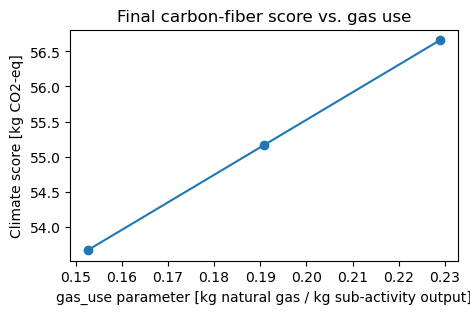

In [20]:
ax = sweep_df.plot(
    x='gas_use',
    y='climate score',
    marker='o',
    legend=False,
    figsize=(5, 3),
)
ax.set_xlabel('gas_use parameter [kg natural gas / kg sub-activity output]')
ax.set_ylabel('Climate score [kg CO2-eq]')
ax.set_title('Final carbon-fiber score vs. gas use')
plt.show()

## 9) Bonus: sample the parameter uncertainty and inject it into Monte Carlo

`ActivityParameter` objects can store uncertainty data, but `bw2calc` does not automatically turn that parameter uncertainty into matrix uncertainty.

A practical workaround is:

1. sample the parameter distributions with `bw2parameters.ParameterSet`
2. convert those parameter samples into exchange samples with the same formulas
3. inject the resulting arrays with `bw_processing.add_persistent_array(...)`

This keeps the parameter dependence explicit and lets the rest of the model keep its normal exchange uncertainty distributions.

In [21]:
iterations = 250

parameter_definitions = {
    ap.name: {'amount': ap.amount, **ap.data}
    for ap in ActivityParameter.select().where(ActivityParameter.group == parameter_group)
}
parameter_sampler = ParameterSet(parameter_definitions)
parameter_samples = parameter_sampler.evaluate_monte_carlo(iterations=iterations)

gas_use_samples = parameter_samples['gas_use']
co2_factor_samples = parameter_samples['co2_factor']
co2_samples = gas_use_samples * co2_factor_samples

sample_summary = pd.DataFrame(
    {
        'gas_use': gas_use_samples,
        'co2_factor': co2_factor_samples,
        'fossil CO2': co2_samples,
    }
).describe(percentiles=[0.05, 0.5, 0.95]).T

sample_summary

,count,mean,std,min,5%,50%,95%,max
gas_use,250.0,0.190183,0.014473,0.155507,0.167782,0.189170,0.215847,0.226678
co2_factor,250.0,3.677811,0.153564,3.159499,3.416913,3.677580,3.935683,4.121751
fossil CO2,250.0,0.699491,0.061109,0.551110,0.602952,0.698802,0.803000,0.886410


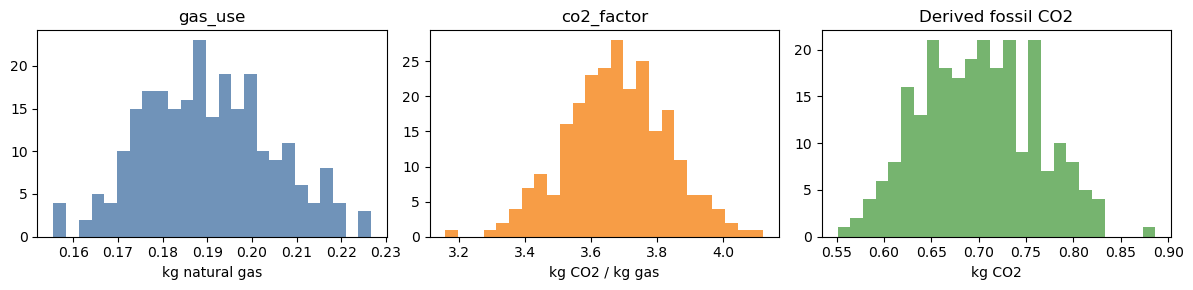

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].hist(gas_use_samples, bins=25, color='#4C78A8', alpha=0.8)
axes[0].set_title('gas_use')
axes[0].set_xlabel('kg natural gas')

axes[1].hist(co2_factor_samples, bins=25, color='#F58518', alpha=0.8)
axes[1].set_title('co2_factor')
axes[1].set_xlabel('kg CO2 / kg gas')

axes[2].hist(co2_samples, bins=25, color='#54A24B', alpha=0.8)
axes[2].set_title('Derived fossil CO2')
axes[2].set_xlabel('kg CO2')

plt.tight_layout()
plt.show()

In [27]:
final_activity = [act for act in bd.Database("carbon fiber") if act["name"] == "carbon fiber production, weaved, at factory"][0]

In [26]:
gas_exc, co2_exc = get_parameterized_exchange_amounts()

demand, data_objs, remapping = bd.prepare_lca_inputs(
    demand={final_activity: 1},
    method=method,
)

dp_parameters = bwp.create_datapackage(sequential=True)
dp_parameters.add_persistent_array(
    matrix='technosphere_matrix',
    indices_array=np.array([(gas_exc.input.id, parameterized_activity.id)], dtype=bwp.INDICES_DTYPE),
    data_array=gas_use_samples.reshape((1, -1)),
    flip_array=np.array([True]),
    name='gas-use-override',
)
dp_parameters.add_persistent_array(
    matrix='biosphere_matrix',
    indices_array=np.array([(co2_exc.input.id, parameterized_activity.id)], dtype=bwp.INDICES_DTYPE),
    data_array=co2_samples.reshape((1, -1)),
    name='co2-override',
)

parameter_lca = bc.LCA(
    demand,
    data_objs=data_objs + [dp_parameters],
    remapping_dicts=remapping,
    use_distributions=True,
    use_arrays=True,
)
parameter_lca.lci()
parameter_lca.lcia()

In [25]:
parameter_score_samples = [parameter_lca.score]
for _ in range(iterations - 1):
    next(parameter_lca)
    parameter_score_samples.append(parameter_lca.score)

score_summary = pd.Series(parameter_score_samples, name='climate score').describe(
    percentiles=[0.05, 0.5, 0.95]
)
score_summary

count    250.000000
mean      88.892460
std       86.198548
min        5.431191
5%        17.125992
50%       59.077592
95%      241.892994
max      572.568065
Name: climate score, dtype: float64

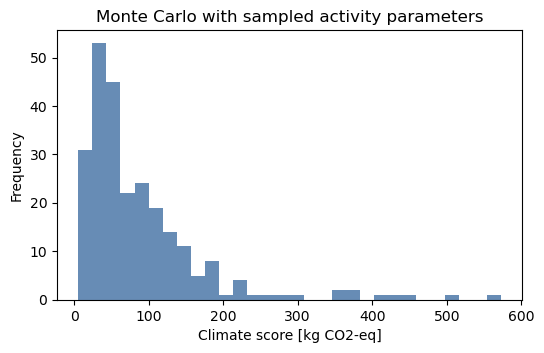

In [29]:
plt.figure(figsize=(6, 3.5))
plt.hist(parameter_score_samples, bins=30, color='#4C78A8', alpha=0.85)
plt.xlabel('Climate score [kg CO2-eq]')
plt.ylabel('Frequency')
plt.title('Monte Carlo with sampled activity parameters')
plt.show()

## Troubleshooting note

If unlinked exchanges remain, do not guess blindly.
Inspect the exact names, reference products, locations, categories, and formulas first, then decide whether the fix belongs in the source file or in a migration.

## Recap

After this notebook, you should now be able to:

- import a realistic foreground Excel file
- inspect unlinked exchanges after the strategy pipeline
- distinguish technosphere and biosphere linking problems
- apply a migration file
- activate workbook parameters during import
- inspect active `ActivityParameter` and `ParameterizedExchange` objects
- recalculate scores after changing parameter values
- build a bonus Monte Carlo from sampled parameter values